#Trabajo Practico N1 - Procesos

####1.- Generar el siguiente arbol de procesos en ANSI C

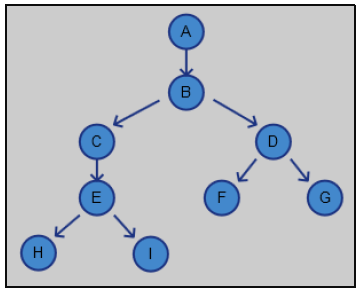

In [4]:
!ls -la

total 16
drwxr-xr-x 1 root root 4096 Apr 30 13:37 .
drwxr-xr-x 1 root root 4096 May  2 18:13 ..
drwxr-xr-x 4 root root 4096 Apr 30 13:37 .config
drwxr-xr-x 1 root root 4096 Apr 30 13:37 sample_data


In [5]:
%%writefile ej-1_ArbolDeProcesos.cpp

#include <stdio.h>
#include <stdlib.h>
#include <sys/wait.h>
#include <unistd.h>

#include <iostream>

using namespace std;

void crear_proceso(char letra) {
  pid_t pid = getpid();
  pid_t ppid = getppid();
  cout << "proceso" << letra << " con PID: " << pid << " PPID: " << ppid
       << endl;

  if (letra == 'A') {
    pid_t b;
    b = fork();
    if (b == 0) {
      crear_proceso('B');
      exit(0);
    }
    sleep(20);
    waitpid(b, NULL, 0);
  } else if (letra == 'B') {
    pid_t c, d;
    c = fork();
    if (c == 0) {
      crear_proceso('C');
      exit(0);
    }
    d = fork();
    if (d == 0) {
      crear_proceso('D');
      exit(0);
    }
    sleep(20);
    waitpid(c, NULL, 0);
    waitpid(d, NULL, 0);
  } else if (letra == 'C') {
    pid_t e;
    e = fork();
    if (e == 0) {
      crear_proceso('E');
      exit(0);
    }
    sleep(20);
    waitpid(e, NULL, 0);
  } else if (letra == 'E') {
    pid_t h, i;
    h = fork();
    if (h == 0) {
      crear_proceso('H');
      sleep(20);
      exit(0);
    }
    i = fork();
    if (i == 0) {
      crear_proceso('I');
      sleep(20);
      exit(0);
    }
    sleep(20);
    waitpid(h, NULL, 0);
    waitpid(i, NULL, 0);
  } else if (letra == 'D') {
    pid_t f, g;
    f = fork();
    if (f == 0) {
      crear_proceso('F');
      exit(0);
    }
    g = fork();
    if (g == 0) {
      crear_proceso('G');
      exit(0);
    }
    sleep(20);
    waitpid(f, NULL, 0);
    waitpid(g, NULL, 0);
  }

  sleep(20);
}

int main() {

  crear_proceso('A');
  sleep(20);


  return 0;
}

Writing ej-1_ArbolDeProcesos.cpp


In [6]:
!ls -la

total 20
drwxr-xr-x 1 root root 4096 May  2 18:18 .
drwxr-xr-x 1 root root 4096 May  2 18:13 ..
drwxr-xr-x 4 root root 4096 Apr 30 13:37 .config
-rw-r--r-- 1 root root 1556 May  2 18:18 ej-1_ArbolDeProcesos.cpp
drwxr-xr-x 1 root root 4096 Apr 30 13:37 sample_data


In [7]:
!g++ ej-1_ArbolDeProcesos.cpp -o ArbolDeProcesos.bin

In [8]:
!ls -la

total 40
drwxr-xr-x 1 root root  4096 May  2 18:25 .
drwxr-xr-x 1 root root  4096 May  2 18:13 ..
-rwxr-xr-x 1 root root 16960 May  2 18:25 ArbolDeProcesos.bin
drwxr-xr-x 4 root root  4096 Apr 30 13:37 .config
-rw-r--r-- 1 root root  1556 May  2 18:18 ej-1_ArbolDeProcesos.cpp
drwxr-xr-x 1 root root  4096 Apr 30 13:37 sample_data


In [19]:
!nohup ./ArbolDeProcesos.bin 1>stdoutC 2>/dev/null &

In [20]:
!ps -ef | grep ArbolDeProcesos.bin

root        4979       1  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4980    4979  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4981    4980  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4982    4980  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4983    4981  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4984    4982  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4985    4983  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4986    4982  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        4987    4983  0 18:33 ?        00:00:00 ./ArbolDeProcesos.bin
root        5000     467  0 18:33 ?        00:00:00 /bin/bash -c ps -ef | grep ArbolDeProcesos.bin
root        5002    5000  0 18:33 ?        00:00:00 grep ArbolDeProcesos.bin


In [21]:
!pstree -p 4979

ArbolDeProcesos(4979)───ArbolDeProcesos(4980)─┬─ArbolDeProcesos(4981)───ArbolDeProcesos(4983)─┬─ArbolDeProcesos(4985)
                                              │                                               └─ArbolDeProcesos(4987)
                                              └─ArbolDeProcesos(4982)─┬─ArbolDeProcesos(4984)
                                                                      └─ArbolDeProcesos(4986)


####2.a - Expique que hace esta porcion de codigo.

In [22]:
!ls -la

total 44
drwxr-xr-x 1 root root  4096 May  2 18:28 .
drwxr-xr-x 1 root root  4096 May  2 18:13 ..
-rwxr-xr-x 1 root root 16960 May  2 18:25 ArbolDeProcesos.bin
drwxr-xr-x 4 root root  4096 Apr 30 13:37 .config
-rw-r--r-- 1 root root  1556 May  2 18:18 ej-1_ArbolDeProcesos.cpp
drwxr-xr-x 1 root root  4096 Apr 30 13:37 sample_data
-rw-r--r-- 1 root root   303 May  2 18:33 stdoutC


In [23]:
# @title Texto de título predeterminado
%%writefile juego_dados.py

from multiprocessing import Process
import random
import time
import sys

PLAYER = 2 #5
THROWS = 10

def player(id):
  sys.stdout.write(f"Jugador {id} entra aljuego.\n")
  points = 0
  for i in range(THROWS):
    dice = random.randint(1, 6)
    points += dice
    sys.stdout.write(f"Jugador {id} - Lanzamiento {i+1}: {dice}\n")
    time.sleep(random.uniform(0.1, 0.3))
  sys.stdout.write(f"Jugador {id} finaliza con {points} puntos.\n")

def main():
  procesos = []
  for i in range(PLAYER):
      p = Process(target=player, args=(i+1,))
      procesos.append(p)
      p.start()

  for p in procesos:
      p.join()

  print("Todos los jugadores han terminado.")

if __name__ == "__main__":
    main()

Writing juego_dados.py


In [24]:
!ls -la

total 48
drwxr-xr-x 1 root root  4096 May  2 19:11 .
drwxr-xr-x 1 root root  4096 May  2 18:13 ..
-rwxr-xr-x 1 root root 16960 May  2 18:25 ArbolDeProcesos.bin
drwxr-xr-x 4 root root  4096 Apr 30 13:37 .config
-rw-r--r-- 1 root root  1556 May  2 18:18 ej-1_ArbolDeProcesos.cpp
-rw-r--r-- 1 root root   700 May  2 19:11 juego_dados.py
drwxr-xr-x 1 root root  4096 Apr 30 13:37 sample_data
-rw-r--r-- 1 root root   303 May  2 18:33 stdoutC


In [26]:
!python juego_dados.py

Jugador 1 entra aljuego.
Jugador 1 - Lanzamiento 1: 6
Jugador 3 entra aljuego.
Jugador 4 entra aljuego.
Jugador 4 - Lanzamiento 1: 4
Jugador 3 - Lanzamiento 1: 6
Jugador 2 entra aljuego.
Jugador 2 - Lanzamiento 1: 3
Jugador 5 entra aljuego.
Jugador 5 - Lanzamiento 1: 6
Jugador 4 - Lanzamiento 2: 5
Jugador 1 - Lanzamiento 2: 2
Jugador 5 - Lanzamiento 2: 2
Jugador 2 - Lanzamiento 2: 1
Jugador 3 - Lanzamiento 2: 5
Jugador 3 - Lanzamiento 3: 3
Jugador 5 - Lanzamiento 3: 5
Jugador 1 - Lanzamiento 3: 1
Jugador 4 - Lanzamiento 3: 5
Jugador 2 - Lanzamiento 3: 4
Jugador 5 - Lanzamiento 4: 6
Jugador 3 - Lanzamiento 4: 1
Jugador 1 - Lanzamiento 4: 6
Jugador 4 - Lanzamiento 4: 6
Jugador 4 - Lanzamiento 5: 2
Jugador 5 - Lanzamiento 5: 4
Jugador 2 - Lanzamiento 4: 2
Jugador 3 - Lanzamiento 5: 2
Jugador 1 - Lanzamiento 5: 6
Jugador 2 - Lanzamiento 5: 5
Jugador 4 - Lanzamiento 6: 1
Jugador 5 - Lanzamiento 6: 6
Jugador 4 - Lanzamiento 7: 3
Jugador 1 - Lanzamiento 6: 4
Jugador 3 - Lanzamiento 6: 1
Jugad

Descripcion: *Este Codigo, representa un juego de tira de dados. Donde la cantidad de jugadores se define en la variable global PLAYER y la catidad de tiradas esta indicada en la variable THROWS.
La funcion player recibe al identificador del jugador y realiza tiradas de dado (THROWS veces), cuando se consumen las tiradas se imprime un mensaje en pantalla "Jugador <nro> finaliza con <int> puntos".
La funcion main va recorriendo los jugadores disponibles (variable PLAYER), donde en cada jugador utiliza la  funcion Process para crear un nuevo proceso apartir de la funcion 'player' con su respectivo argumento. Tambien estos nuevos procesos los va añadiendo a una lista reprsentada con la variable 'procesos'. Finalmente luego de ejecutar/lanzar estos procesos creados por CADA jugador, aguarda la finalizacion de estos procesos para poder terminar  la ejecucion del main.*

####2.b - Desarrollo del mismo programa pero utilizando fork()

In [27]:
%%writefile juego_dados_fork.py
import sys
import os
import time
import random

PLAYER = 5
THROWS = 10

def player(id):
  sys.stdout.write(f"Jugador {id} entra al juego.\n")
  points = 0
  for i in range(THROWS):
    dice = random.randint(1, 6)
    points += dice
    sys.stdout.write(f"Jugador {id} - Lanzamiento {i+1}: {dice}\n")
    time.sleep(random.uniform(0.1, 0.3))
  sys.stdout.write(f"Jugador {id} finaliza con {points} puntos.\n")

def main():
  for i in range(PLAYER):
    pid = os.fork()

    if pid < 0:
      sys.exit("Error al crear el nuevo proceso")

    if pid == 0:
      player(i + 1)
      sys.exit(0)

  for _ in range(PLAYER):
    os.wait()

  print("Todos los jugadores han terminado.")

if __name__ == "__main__":
    main()

Writing juego_dados_fork.py


In [28]:
!ls -la

total 52
drwxr-xr-x 1 root root  4096 May  2 20:56 .
drwxr-xr-x 1 root root  4096 May  2 18:13 ..
-rwxr-xr-x 1 root root 16960 May  2 18:25 ArbolDeProcesos.bin
drwxr-xr-x 4 root root  4096 Apr 30 13:37 .config
-rw-r--r-- 1 root root  1556 May  2 18:18 ej-1_ArbolDeProcesos.cpp
-rw-r--r-- 1 root root   718 May  2 20:56 juego_dados_fork.py
-rw-r--r-- 1 root root   700 May  2 19:11 juego_dados.py
drwxr-xr-x 1 root root  4096 Apr 30 13:37 sample_data
-rw-r--r-- 1 root root   303 May  2 18:33 stdoutC


In [29]:
!python juego_dados_fork.py

Jugador 1 entra al juego.
Jugador 1 - Lanzamiento 1: 2
Jugador 3 entra al juego.
Jugador 3 - Lanzamiento 1: 4
Jugador 4 entra al juego.
Jugador 4 - Lanzamiento 1: 3
Jugador 2 entra al juego.
Jugador 2 - Lanzamiento 1: 2
Jugador 5 entra al juego.
Jugador 5 - Lanzamiento 1: 1
Jugador 3 - Lanzamiento 2: 4
Jugador 4 - Lanzamiento 2: 3
Jugador 5 - Lanzamiento 2: 1
Jugador 2 - Lanzamiento 2: 2
Jugador 1 - Lanzamiento 2: 5
Jugador 5 - Lanzamiento 3: 2
Jugador 1 - Lanzamiento 3: 2
Jugador 3 - Lanzamiento 3: 6
Jugador 4 - Lanzamiento 3: 4
Jugador 2 - Lanzamiento 3: 6
Jugador 5 - Lanzamiento 4: 6
Jugador 1 - Lanzamiento 4: 1
Jugador 4 - Lanzamiento 4: 2
Jugador 3 - Lanzamiento 4: 3
Jugador 2 - Lanzamiento 4: 5
Jugador 1 - Lanzamiento 5: 4
Jugador 3 - Lanzamiento 5: 2
Jugador 5 - Lanzamiento 5: 1
Jugador 4 - Lanzamiento 5: 5
Jugador 1 - Lanzamiento 6: 2
Jugador 2 - Lanzamiento 5: 6
Jugador 1 - Lanzamiento 7: 4
Jugador 3 - Lanzamiento 6: 2
Jugador 5 - Lanzamiento 6: 1
Jugador 4 - Lanzamiento 6: 4


####3.- La mansion Derceto.

In [1]:
!mkdir ./3mansion

In [2]:
cd 3mansion/

/content/3mansion


In [3]:
%%writefile EventoParanormal.java
import java.util.Random;

public class EventoParanormal {
    private static final String[] eventos = {
        "Sin actividad",
        "Movimiento detectado",
        "Anomalía térmica",
        "Sombra extraña",
        "Ruido detectado"
    };

    private static final double[] probabilidades = {
        0.5,  // Sin actividad (50%)
        0.7,  // Movimiento detectado (20%)
        0.8,  // Anomalía térmica (10%)
        0.9,  // Sombra extraña (10%)
        1.0   // Ruido detectado (10%)
    };

    private static final Random random = new Random();

    public static String generarEvento() {
        double r = random.nextDouble();
        for (int i = 0; i < probabilidades.length; i++) {
            if (r < probabilidades[i]) {
                return eventos[i];
            }
        }
        return eventos[0]; // fallback
    }

    public static boolean esParanormal(String evento) {
        return !evento.equals("Sin actividad");
    }
}

Writing EventoParanormal.java


In [4]:
%%writefile LoggerCamara.java
import java.io.FileWriter;
import java.io.IOException;
import java.io.PrintWriter;
import java.time.LocalDateTime;
import java.time.format.DateTimeFormatter;

public class LoggerCamara {
    private final PrintWriter writer;
    private final DateTimeFormatter dtf = DateTimeFormatter.ofPattern("yyyy-MM-dd HH:mm:ss");

    public LoggerCamara(String fileName) throws IOException {
        this.writer = new PrintWriter(new FileWriter(fileName));
    }

    public void log(String mensaje) {
        String timestamp = LocalDateTime.now().format(dtf);
        writer.println(timestamp + " | " + mensaje);
        writer.flush();
    }

    public void cerrar() {
        writer.close();
    }
}

Writing LoggerCamara.java


In [5]:
%%writefile CamaraProceso.java
public class CamaraProceso {
    public static void main(String[] args) {
        if (args.length < 4) {
            System.out.println("Uso: java CamaraProceso    ");
            System.exit(1);
        }

        int id = Integer.parseInt(args[0]);
        String zona = args[1];
        int duracion = Integer.parseInt(args[2]);
        int frecuencia = Integer.parseInt(args[3]);

        if (duracion <= 0 || frecuencia <= 0) {
            System.err.println("Duración y frecuencia deben ser mayores que cero.");
            System.exit(1);
        }

        int eventosParanormales = 0;
        String logFile = "camara_" + id + "_" + zona + ".log";

        try {
            LoggerCamara logger = new LoggerCamara(logFile);
            long inicio = System.currentTimeMillis();
            long tiempoTotal = duracion * 1000L;

            while ((System.currentTimeMillis() - inicio) < tiempoTotal) {
                String evento = EventoParanormal.generarEvento();
                logger.log("CÁMARA " + id + " | ZONA: " + zona + " | EVENTO: " + evento);

                if (EventoParanormal.esParanormal(evento)) {
                    eventosParanormales++;
                }

                try {
                    Thread.sleep(frecuencia * 1000L);
                } catch (InterruptedException e) {
                    logger.log("Cámara " + id + " interrumpida.");
                    break;
                }
            }

            logger.log("CÁMARA " + id + " finaliza con " + eventosParanormales + " eventos paranormales detectados.");
            logger.cerrar();
        } catch (Exception e) {
            System.err.println("Error en cámara " + id + ": " + e.getMessage());
            e.printStackTrace();
        }
    }
}

Writing CamaraProceso.java


In [6]:
%%writefile MansionDercetoMonitor.java
import java.io.*;
import java.util.*;

public class MansionDercetoMonitor {
    public static void main(String[] args) {
        if (args.length < 2) {
            System.out.println("Uso: java MansionDercetoMonitor  ");
            System.exit(1);
        }

        int duracion = 0, frecuencia = 0;

        try {
            duracion = Integer.parseInt(args[0]);
            frecuencia = Integer.parseInt(args[1]);

            if (duracion <= 0 || frecuencia <= 0) {
                System.err.println("Duración y frecuencia deben ser mayores que cero.");
                System.exit(1);
            }
        } catch (NumberFormatException e) {
            System.err.println("La duración y frecuencia deben ser enteros.");
            System.exit(1);
        }

         String[] zonas = {
            "Sotano",
            "Atico",
            "Cocina",
            "Dormitorio",
            "Jardin",
            "Mausoleo"
        };

        List<Process> procesos = new ArrayList<>();
        List<String> logFiles = new ArrayList<>();

        for (int i = 0; i < zonas.length; i++) {
            String zona = zonas[i];
            String logFile = "camara_" + (i + 1) + "_" + zona + ".log";
            logFiles.add(logFile);

            try {
                ProcessBuilder pb = new ProcessBuilder(
                        "java", "CamaraProceso",
                        String.valueOf(i + 1),
                        zona,
                        String.valueOf(duracion),
                        String.valueOf(frecuencia)
                );
                pb.directory(new File("."));
                Process proceso = pb.start();
                procesos.add(proceso);
            } catch (IOException e) {
                System.err.println("Error iniciando camara " + (i + 1));
                e.printStackTrace();
            }
        }

        // Esperar a que terminen todas las camaras
        for (Process proceso : procesos) {
            try {
                proceso.waitFor();
            } catch (InterruptedException e) {
                System.err.println("Error esperando una camara.");
                e.printStackTrace();
            }
        }

         System.out.println("\nMonitoreo finalizado. Lectura de logs:");

        System.out.println("\n======= LOG DE TODAS LAS CaMARAS =======\n");
        for (String file : logFiles) {
            System.out.println(">>> " + file);
            try (BufferedReader reader = new BufferedReader(new FileReader(file))) {
                String linea;
                while ((linea = reader.readLine()) != null) {
                    System.out.println(linea);
                }
            } catch (IOException e) {
                System.err.println("No se pudo leer el archivo: " + file);
            }
            System.out.println(); // Espacio entre logs
        }

        System.out.println("Monitoreo completo.");
    }
}

Writing MansionDercetoMonitor.java


In [7]:
!ls -la

total 24
drwxr-xr-x 2 root root 4096 May  3 06:09 .
drwxr-xr-x 1 root root 4096 May  3 06:09 ..
-rw-r--r-- 1 root root 1762 May  3 06:09 CamaraProceso.java
-rw-r--r-- 1 root root  969 May  3 06:09 EventoParanormal.java
-rw-r--r-- 1 root root  695 May  3 06:09 LoggerCamara.java
-rw-r--r-- 1 root root 2922 May  3 06:09 MansionDercetoMonitor.java


In [8]:
!javac *.java

In [9]:
!java MansionDercetoMonitor 10 2


Monitoreo finalizado. Lectura de logs:

======= LOG DE TODAS LAS CaMARAS =======

>>> camara_1_Sotano.log
2025-05-03 06:10:21 | CÁMARA 1 | ZONA: Sotano | EVENTO: Sin actividad
2025-05-03 06:10:23 | CÁMARA 1 | ZONA: Sotano | EVENTO: Ruido detectado
2025-05-03 06:10:25 | CÁMARA 1 | ZONA: Sotano | EVENTO: Sombra extraña
2025-05-03 06:10:27 | CÁMARA 1 | ZONA: Sotano | EVENTO: Ruido detectado
2025-05-03 06:10:29 | CÁMARA 1 | ZONA: Sotano | EVENTO: Anomalía térmica
2025-05-03 06:10:31 | CÁMARA 1 finaliza con 4 eventos paranormales detectados.

>>> camara_2_Atico.log
2025-05-03 06:10:21 | CÁMARA 2 | ZONA: Atico | EVENTO: Movimiento detectado
2025-05-03 06:10:23 | CÁMARA 2 | ZONA: Atico | EVENTO: Sin actividad
2025-05-03 06:10:25 | CÁMARA 2 | ZONA: Atico | EVENTO: Movimiento detectado
2025-05-03 06:10:27 | CÁMARA 2 | ZONA: Atico | EVENTO: Sin actividad
2025-05-03 06:10:29 | CÁMARA 2 | ZONA: Atico | EVENTO: Sin actividad
2025-05-03 06:10:31 | CÁMARA 2 finaliza con 2 eventos paranormales detect